In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
import twixtools
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy import ndimage
import recon_plot_helpers
import save_data_helpers
from ismrm_figs import mvf_utils
import nibabel as nib

### Load motion-corrected recon from ADMM (final iteration)

In [9]:
iter_num = 9
# admm_base_dir_subject2 = f"/data/lilianae/ADMM_results/new_gating/New_Gating_George_400sp/"
admm_base_dir_subject3 = f"/data/lilianae/ADMM_results/Subject3_ADMM/"
img_gates, lam, tmp, tmp_inv = mvf_utils.load_admm_output(base_dir=admm_base_dir_subject3,
                                                          iter_num=9,
                                                          verbose=True)
num_gates = img_gates.shape[0]

tmp_inv_admm.shape = (5, 58, 512, 512, 3)
tmp_admm.shape = (5, 58, 512, 512, 3)
z_abs.shape = (5, 58, 512, 512)


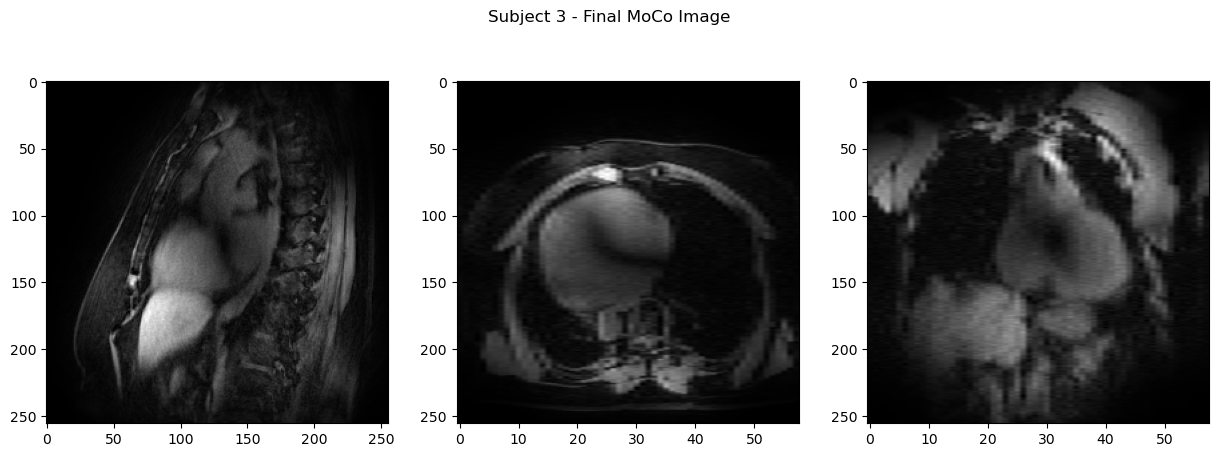

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [12]:
oshape = (58, 256, 256)
lam_final_cropped = recon_plot_helpers.crop_xy_dimension(lam, oshape=oshape)
recon_plot_helpers.plot_recons_all_axes(np.abs(lam_final_cropped), title="Subject 3 - Final MoCo Image")

### Save Gated Images ($z_s$), Motion-Corrected Image ($\lambda$) as NiFTI

In [14]:
def save_as_nifti(data, output_path, voxel_size=(5.0, 1.172, 1.172)):
    """
    Save 3D numpy array as NIfTI file with specified voxel spacing.
    
    Parameters:
    -----------
    data : numpy.ndarray
        3D array of shape (z, y, x) = (58, 256, 256)
    output_path : str
        Path where to save the .nii or .nii.gz file
    voxel_size : tuple
        Voxel dimensions in mm as (z, y, x)
    """
    data = np.array(data, dtype=np.float32)
    print(f'data.shape = {data.shape}')
    
    # Create affine matrix with voxel spacing
    affine = np.diag([voxel_size[2], voxel_size[1], voxel_size[0], 1.0])

    # Create NIfTI image
    nifti_img = nib.Nifti1Image(data.T, affine)  # Transpose for correct orientation
    print(nifti_img.shape)

    nib.save(nifti_img, output_path)
    print(f"Saved image: {output_path}")

## Save final motion-corrected image
output_dir = '/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files'
save_as_nifti(lam_final_cropped, os.path.join(output_dir, f'subject3_lam_400sp_admm.nii'))

## Save each individual gate image
for gate in range(num_gates):
    img_gate_cropped = recon_plot_helpers.crop_xy_dimension(img_gates[gate], oshape=oshape)
    save_as_nifti(img_gate_cropped, os.path.join(output_dir, f"z_{gate}_400sp_admm.nii"))


data.shape = (58, 256, 256)
(256, 256, 58)
Saved image: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/subject3_lam_400sp_admm.nii
data.shape = (58, 256, 256)
(256, 256, 58)
Saved image: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/z_0_400sp_admm.nii
data.shape = (58, 256, 256)
(256, 256, 58)
Saved image: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/z_1_400sp_admm.nii
data.shape = (58, 256, 256)
(256, 256, 58)
Saved image: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/z_2_400sp_admm.nii
data.shape = (58, 256, 256)
(256, 256, 58)
Saved image: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/z_3_400sp_admm.nii
data.shape = (58, 256, 256)
(256, 256, 58)
Saved image: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/z_4_400sp_admm.nii


### 2. Load MVFs from ADMM

In [15]:
def plot_motion_all_axes(recon, z_idx=None, y_idx=None, x_idx=None, cmap="gray",
                         title="", save_fig=False, output_dir=""):
    """
    Plot single 3D reconstruction across all views

    Inputs
    -------------------------------
    recon : ndarray
        3D image
    z_idx, y_idx, x_idx : int
        Indices to view across each axis
    title : str
        Title for plot
    save_fig : bool, Optional
        Default = False, save figure if true
    output_dir : str, Optional
        Set to "", directory to save figure

    Outputs
    -------------------------------
    fig, axs: matplotlib objects
    
    """
    Nz, Ny, Nx = recon.shape

    recon = np.abs(recon)
    
    if z_idx is None:
        z_idx = Nz//2
    if y_idx is None:
        y_idx = Ny//2
    if x_idx is None:
        x_idx = Nx//2

    fig, ax = plt.subplots(1,3, figsize=(15, 5))
    # aspect = Nz/Nx
    ax[0].imshow(np.fliplr(recon[z_idx, :, :]), cmap=cmap, aspect=Ny/Nx)
    ax[1].imshow(np.rot90(recon[:, y_idx, :], k=-3), cmap=cmap, aspect=Nz/Nx)
    ax[2].imshow(np.rot90(recon[:, :, x_idx], k=-1), cmap=cmap, aspect=Nz/Ny)
    fig.suptitle(f"{title}")
    
    if save_fig:
        if output_dir=="":
            raise Exception("Must provide output directory/filename to save figure.")
        else:
            plt.savefig(output_dir)

    plt.show()


New array shape = (5, 58, 256, 256, 3)


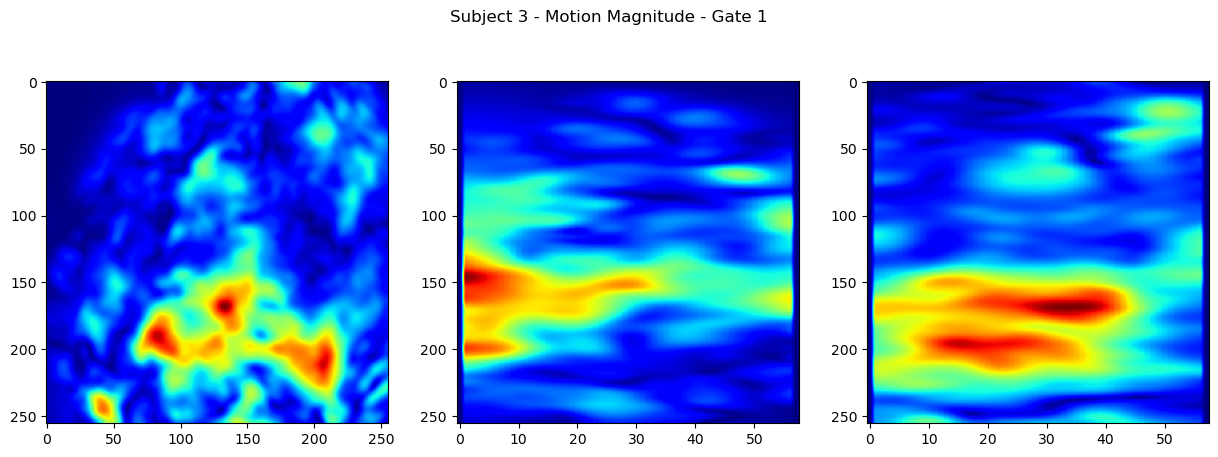

cropped_tmp.shape = (5, 58, 256, 256, 3)


In [16]:
oshape = (58, 256, 256)

## Motion vectors
cropped_tmp = mvf_utils.crop_gated_mvfs(tmp, oshape)
# Assuming tmp_mvf is shape (Nz, Ny, Nx, 3, n_gates) from the saved file
gate_idx = 1
mvf_gate = cropped_tmp[gate_idx,...] # Shape: (Nz, Ny, Nx, 3)

# Calculate magnitude: sqrt(dx^2 + dy^2 + dz^2)
motion_mag = np.sqrt(np.sum(mvf_gate**2, axis=-1)) # Shape: (Nz, Ny, Nx)

# Plot using your existing function
plot_motion_all_axes(motion_mag, cmap='jet',title=f"Subject 3 - Motion Magnitude - Gate {gate_idx}")
print(f'cropped_tmp.shape = {cropped_tmp.shape}')

### Save motion fields as NIFTI

In [17]:
def save_itk_vector_field(mvf_3d, voxel_size, output_path):
    """
    mvf_3d: (Nz, Ny, Nx, 3) 
    voxel_dims: (dz, dy, dx) in mm
    """
    # 1. Convert Voxel Units to Physical Units (mm)
    # This is required for ITK-SNAP/Registration to interpret displacement correctly
    mvf_mm = np.zeros_like(mvf_3d, dtype=np.float32)
    mvf_mm[..., 0] = mvf_3d[..., 0] * voxel_size[0] # dz -> mm
    mvf_mm[..., 1] = mvf_3d[..., 1] * voxel_size[1] # dy -> mm
    mvf_mm[..., 2] = mvf_3d[..., 2] * voxel_size[2] # dx -> mm

    # 2. Reorder spatial axes and vector components
    # Original: (z, y, x) with components [dz, dy, dx]
    # NIfTI goal: (x, y, z) with components [dx, dy, dz]
    
    # 2a. move spatial axes to (x, y, z)
    # (z=0, y=1, x=2, comp=3) -> (x=2, y=1, z=0, comp=3)
    data_transposed = np.transpose(mvf_mm, (2, 1, 0, 3))
    
    # 2b. reorder the components inside the last dimension to [dx, dy, dz]
    # Currently it is [dz, dy, dx] (indices 0, 1, 2)
    data_final = data_transposed[..., [2, 1, 0]]

    # 3. Use the same Affine as lam
    affine = np.diag([voxel_size[2], voxel_size[1], voxel_size[0], 1.0])

    # 4. Save as NIfTI
    # We add a 4th empty dimension to satisfy the (X, Y, Z, 1, 3) convention for some ITK tools
    nifti_img = nib.Nifti1Image(data_final[:, :, :, np.newaxis, :], affine)
    
    ## Set intent to 'vector' so ITK-SNAP knows this isn't a movie, but a displacement field
    nifti_img.header.set_intent('vector', (), '')
    
    nib.save(nifti_img, output_path)
    print(f"Saved Vector Field: {output_path}")


## Save both mvf (lambda to z) and mvf_inv (z to lambda)
voxel_size=(5.0, 1.172, 1.172)
oshape=(58, 256, 256)

## Crop mvfs to fit image
mvfs_lam_to_z = mvf_utils.crop_gated_mvfs(tmp, oshape=oshape)
mvfs_z_to_lam = mvf_utils.crop_gated_mvfs(tmp_inv, oshape=oshape)

for gate in range(num_gates):

    ## Save mvfs as Nifti vector fields
    mvf_base_dir = "/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files"
    save_itk_vector_field(mvf_3d=mvfs_lam_to_z[gate], voxel_size=voxel_size, 
                            output_path=os.path.join(mvf_base_dir,f"mvf_lam_to_z{gate}.nii"))
    save_itk_vector_field(mvf_3d=mvfs_z_to_lam[gate], voxel_size=voxel_size, 
                            output_path=os.path.join(mvf_base_dir,f"mvf_z{gate}_to_lam.nii"))

New array shape = (5, 58, 256, 256, 3)
New array shape = (5, 58, 256, 256, 3)
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_lam_to_z0.nii
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_z0_to_lam.nii
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_lam_to_z1.nii
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_z1_to_lam.nii
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_lam_to_z2.nii
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_z2_to_lam.nii
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_lam_to_z3.nii
Saved Vector Field: /home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/mvf_z3_to_lam.nii
Saved Vect

In [ ]:
import SimpleITK as sitk

def apply_warp_sitk(image_path, field_path, output_path):
    # 1. Load the image and the displacement field
    moving_img = sitk.ReadImage(image_path)
    field = sitk.ReadImage(field_path)

    # 2. Convert the displacement field to a Transform object
    # SimpleITK expects the field to be in mm and physical space
    transform = sitk.DisplacementFieldTransform(sitk.Cast(field, sitk.sitkVectorFloat64))

    # 3. Resample (Warp)
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(moving_img) # Output grid
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetTransform(transform)
    
    warped_img = resampler.Execute(moving_img)

    # 4. Save
    sitk.WriteImage(warped_img, output_path)
    print(f"Warped image saved to {output_path}")


# output_nifti_path = '/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/'
# lam = os.path.join(output_nifti_path, 'subject3_lam_400sp_admm.nii')
# mvf_lam_to_z = 

# apply_warp_sitk("subject2_mid0082_lam_400sp_admm.nii", "subject2_mid0082_mvf_gate4_400sp_admm.nii", "lam_to_gate4_result.nii.gz")

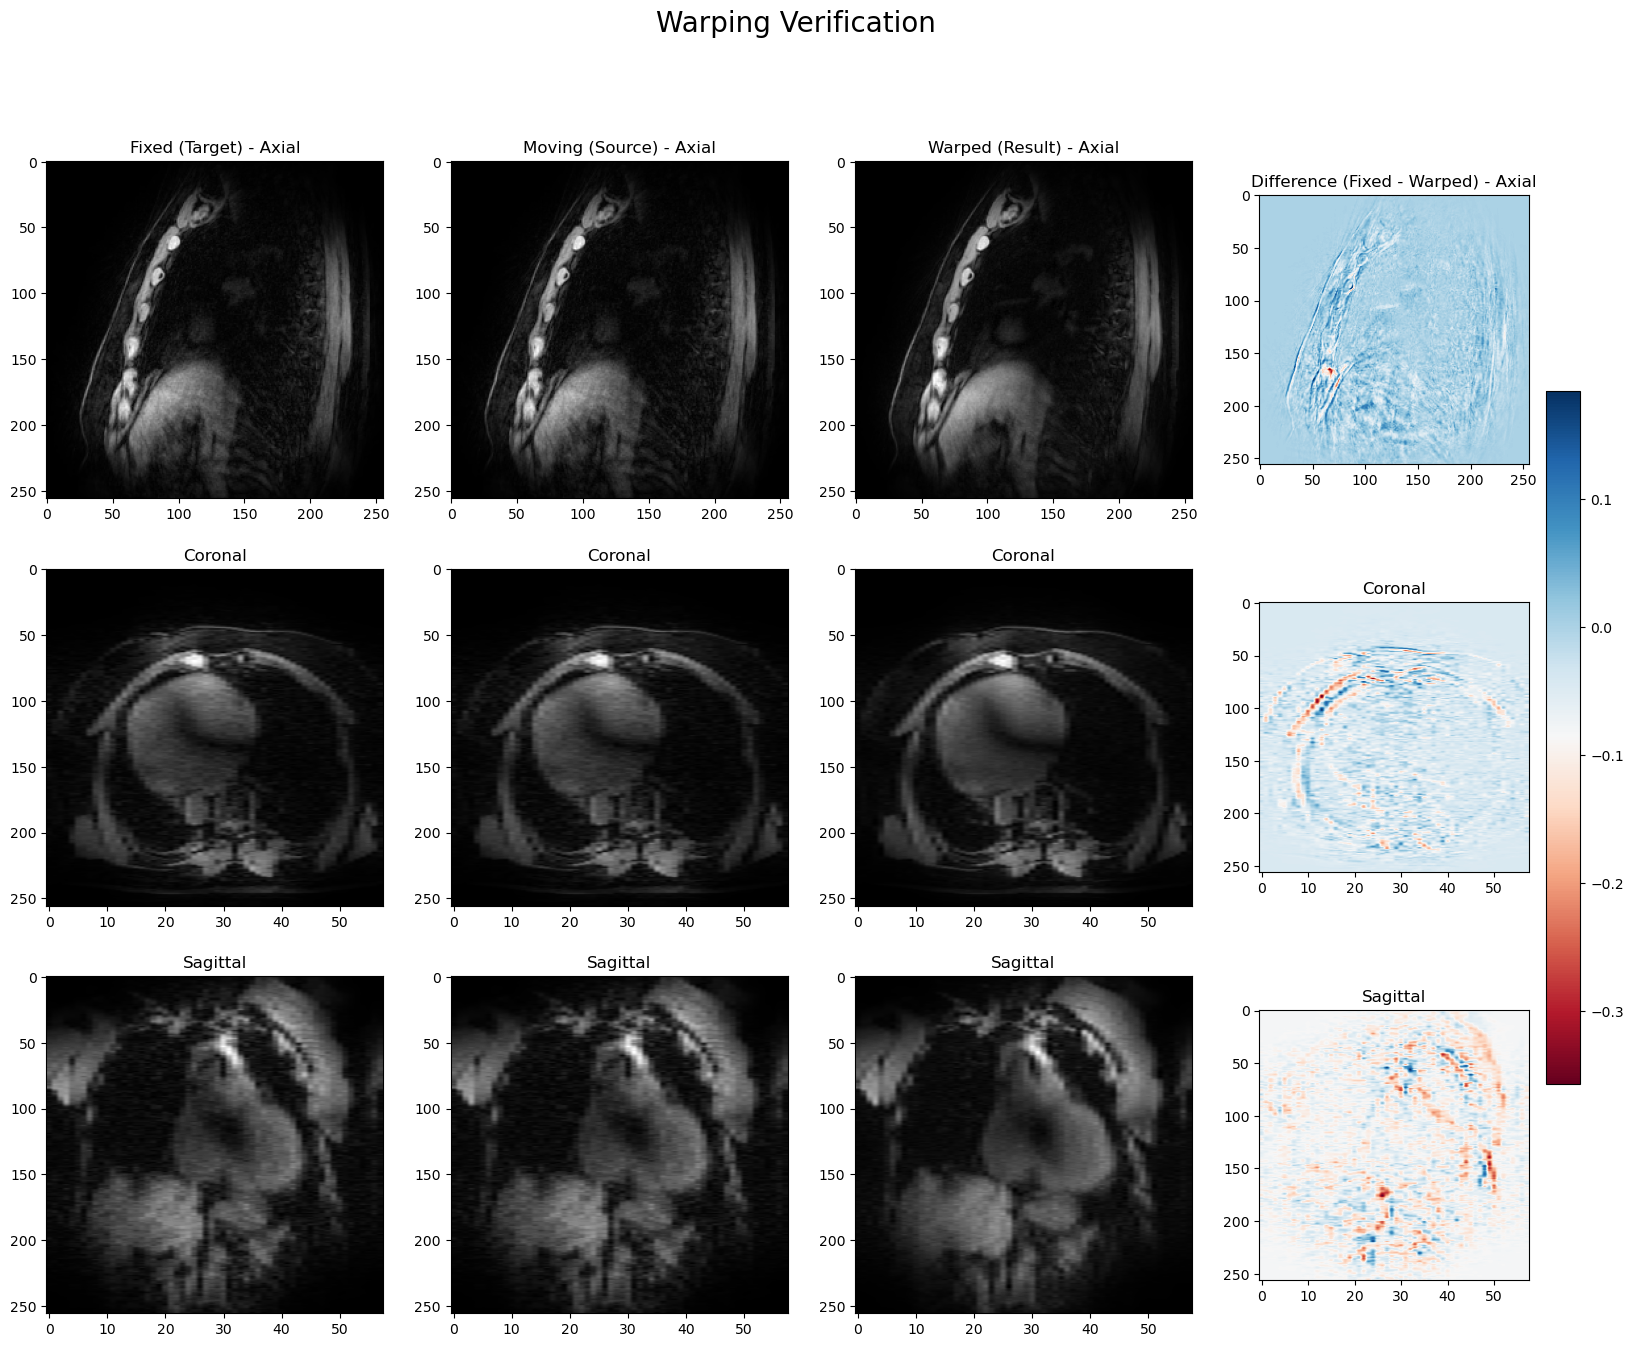

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

def plot_warping_verification(fixed, moving, warped, z_idx=None, y_idx=None, x_idx=None, title="Warping Verification"):
    """
    fixed, moving, warped: 3D numpy arrays (Nz, Ny, Nx)
    """
    images = [fixed, moving, warped]
    names = ['Fixed (Target)', 'Moving (Source)', 'Warped (Result)']
    
    Nz, Ny, Nx = fixed.shape
    if z_idx is None: z_idx = 36
    if y_idx is None: y_idx = Ny // 2
    if x_idx is None: x_idx = Nx // 2

    # We also calculate the difference to see residuals
    diff_before = fixed - moving
    diff_after = fixed - warped
    
    fig, axs = plt.subplots(3, 4, figsize=(20, 15))
    
    for i, img in enumerate(images + [diff_after]):
        col_name = names[i] if i < 3 else "Difference (Fixed - Warped)"
        
        # --- Axial ---
        ax_img = np.fliplr(img[z_idx, :, :])
        im0 = axs[0, i].imshow(ax_img, cmap='gray' if i < 3 else 'RdBu', aspect=Ny/Nx)
        axs[0, i].set_title(f"{col_name} - Axial")
        
        # --- Coronal ---
        cor_img = np.rot90(img[:, y_idx, :], k=-3)
        axs[1, i].imshow(cor_img, cmap='gray' if i < 3 else 'RdBu', aspect=Nz/Nx)
        axs[1, i].set_title("Coronal")
        
        # --- Sagittal ---
        sag_img = np.rot90(img[:, :, x_idx], k=-1)
        axs[2, i].imshow(sag_img, cmap='gray' if i < 3 else 'RdBu', aspect=Nz/Ny)
        axs[2, i].set_title("Sagittal")

    # Add colorbar for the difference column only
    plt.colorbar(im0, ax=axs[:, 3], shrink=0.6)
    
    fig.suptitle(title, fontsize=20)
    # plt.tight_layout()
    plt.show()

ref_img = sitk.GetArrayFromImage(sitk.ReadImage("/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/z_0_400sp_admm.nii"))
gate_img = sitk.GetArrayFromImage(sitk.ReadImage("/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/z_0_400sp_admm.nii"))
warped_ref= sitk.GetArrayFromImage(sitk.ReadImage("/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files/subject3_lam_400sp_admm.nii"))
plot_warping_verification(ref_img, gate_img, warped_ref)